In [1]:
import pandas as pd
import matplotlib.pyplot as mp

In [2]:
def extractor(link):
    """
    Takes a given csv file as an input, and extracts it into data frame

    Arguments:
        link(str): URL of a CSV file to be extracted

    Returns:
        file: DataFrame formed after reading the CSV
    """
    return pd.read_csv(link)

IMO, TST and PTST represents three of the tests which are being compared. These tests are discussed in detail in the report.

In [3]:
def per_year_accumulator(link1_imo:str,link2_txt:str, link3_pretxt:str):
    """
    Synchronizes IMO, TST, and PTST datasets via an inner join based on participant names. This handles inconsistent naming convention across datasets.

    Arguments:
        link1_imo(str): URL of a CSV file(IMO) to be extracted
        link2_txt(str): URL of a CSV file(TST) to be extracted
        link3_pretxt(str): URL of a CSV file(PTST) to be extracted

    Returns:
        final: Processed DataFrame formed after merging 3 other DataFrames with ("Name") as common data.

    """
    imo =extractor(link1_imo)
    txt = extractor(link2_txt)
    pre_txt= extractor(link3_pretxt)
    list_of_data= [imo, txt, pre_txt]
    #While the data was sourced, in some of the data the "Contestant" was placed in place of "name". This code fixes that so that code merges properly
    for data in list_of_data:
        if "Contestant" in data.columns:
            data.rename(columns={"Contestant": "Name"}, inplace=True)

        if "name" in data.columns:
            data.rename(columns={"name": "Name"}, inplace=True)
    #merges two data on the basis of similarity in name, through this the people who didn't attend all the tests are filtered out.
    mix_2=pd.merge(imo, txt, on="Name")
    #There are 3 data so the files need to be mixed again
    final=pd.merge(mix_2, pre_txt, on="Name")
    return final




In [4]:
def set_index(data):
    """
    Sets Index of a particular dataframe by their name
    """
    data=data.set_index("Name")
    return data


In [5]:
def normalize_score(file, name:str, scale:int):
    """
    Normalizes the data to a scale of 42 to ensure fair calculation

    Arguments:
        file: The DataFrame which contains processed relevant data for all three tests.
        name(str): The name of the test
        scale(int): The normalization scale to which data is converted

    Returns:
        The new DataFrame file processed after normalization
    """
    return ((file[name]/scale)*42).round(1)#Returns marks on scale of 42

In [8]:
def reducing_anomaly(file, name:str, scale:int, basis:str):
    """
    Filters out the data(used for anomaly) based on the references provided

    Arguments:
        file: The DataFrame which contains processed relevant data for all three tests.
        name(str): Name of the tests to be filtered out
        scale(int): The numerical value based on which data is filtered
        basis(str): The strings which represent on what basis the DataFrame should be filtered out.

    Returns:
            The new DataFrame file with necessary filtering

    """

    if basis.title()=="Lower":
     return file[file[name]>scale]
    return file[file[name]<scale]
    #filters out the dataset on a particular scale to reduce anomaly

In [9]:
def compare(file, year:int):
    """
    Forms Scatter plot with horizontal lines marked for differences

    Arguments:
        file: The DataFrame which contains processed relevant data for all three tests.
        year(int): The year for which the scatter plot if formed

    """
    mp.scatter(file["PTST"], file["IMO"], label="PTST", alpha=0.6)
    mp.scatter(file["TST"], file["IMO"], label="TST", alpha=0.6)
    mp.hlines(file["IMO"],file["PTST"], file["TST"], color="gray", alpha=0.5)#alpha is used to reduce transparency to remove confusion made by overlapping plots


    mp.xlabel("TST and PTST Scores")
    mp.ylabel("IMO Score")
    mp.title(f"Internal and External results comparision {year}")
    mp.legend()#used to analyze graph on the basis of color they are plotted

    mp.savefig(f"{year}_compare.png", dpi=3000)#used to save a picture in order to present it in findings
    mp.show()
    #prints out scatter plot for a particular year

H lines are used in "compare" function to visualize the variance between tests for each candidate

In [10]:
def call_and_calculate(file, score_imo, score_pretst, score_tst):
    """
    Forms a dataframe with only three required data present

    Arguments:
        file: The DataFrame which contains processed relevant data for all three tests.
        score_imo: Reference for list of IMO scores achieved by candidates in a year
        score_pretst: Reference for list of Pre-TST scores achieved by candidates in a year
        score_tst: Reference for list of TST scores achieved by candidates in a year

    Returns:
        (comparing) A final single DataFrame with all required data
    """
    comparing= pd.DataFrame({"Name":file["Name"], "IMO":file[score_imo],"TST":file[score_tst], "PTST":file[score_pretst]})
    return comparing

In [11]:
def mean_calc(file, year:int):
    """
    Forms a bar chart for means across different years

    Arguments:
        file:The DataFrame which contains processed relevant data for all three tests.
        year(int): The year for which the mean score is calculated
    """
    mp.figure(figsize=(8,10))
    (file.mean()).plot(kind="bar", color=["Blue","Green","Red"])
    mp.xlabel("Tests")
    mp.ylabel("Scores")
    mp.title(f"Mean scores of all the tests for {year}")

    mp.savefig(f"{year}_mean.png", dpi=300)#Images saved for future reference

In [12]:
final_2025= per_year_accumulator("imo 2025.csv", "2081 tst.csv", "2081pretst.csv")
comparing_2025= call_and_calculate(final_2025, "Total_x", "Total","TST")# Entering the values equivalent to IMO, PTST and TST scores.
comparing_2025["PTST"]= normalize_score(comparing_2025, "PTST", 28)#Normalization to 42
comparing_2025=set_index(comparing_2025)
#returns dataframe for 2025 with three scores:IMO,TST and PTST for comparison




The values for IMO,TST and PTST entered in call_and_calculate function differs from year, this is because the data was collected from real world sources, where different data contained different names.

In [13]:
final_2024=per_year_accumulator("2024res.csv","2080_tst.csv","2080_ptst.csv")
comparing_2024= call_and_calculate(final_2024,"Total", "total_y", "total_x")
comparing_2024["TST"]= normalize_score(comparing_2024, "TST", 35)
comparing_2024["PTST"]= normalize_score(comparing_2024, "PTST", 28)#Normalization to 42
comparing_2024=set_index(comparing_2024)
#returns dataframe for 2024 with three scores:IMO,TST and PTST for comparison



In [14]:
final_2023= per_year_accumulator("imo_2023_official_nepal.csv", "2079tst.csv", "2079 pretst.csv")
comparing_2023= call_and_calculate(final_2023,"Total_x","Total_y","Total Score (Final + Viva)")
comparing_2023["PTST"]= normalize_score(comparing_2023, "PTST", 28)
comparing_2023["TST"]= normalize_score(comparing_2023, "TST", 50)#Normalization to 42
comparing_2023=set_index(comparing_2023)
#returns dataframe for 2024 with three scores:IMO,TST and PTST for comparison

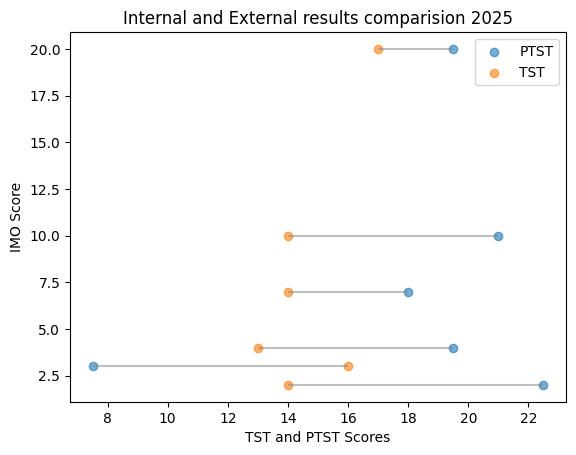

In [15]:
compare(comparing_2025, 2025)#calls function compare to print graph for 2025

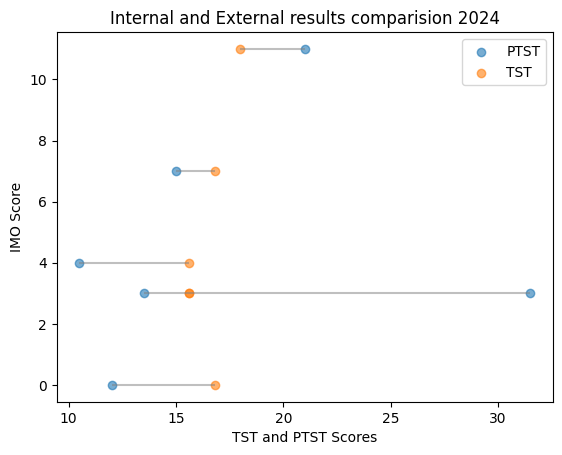

In [16]:
compare(comparing_2024, 2024)#calls function compare to print graph for 2024

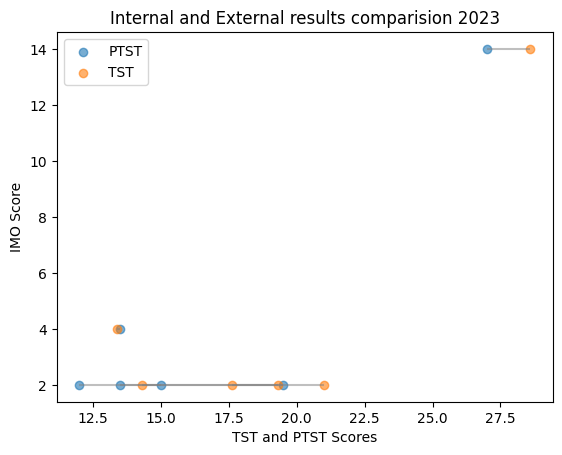

In [17]:
compare(comparing_2023,2023)#calls function compare to print graph for 2023

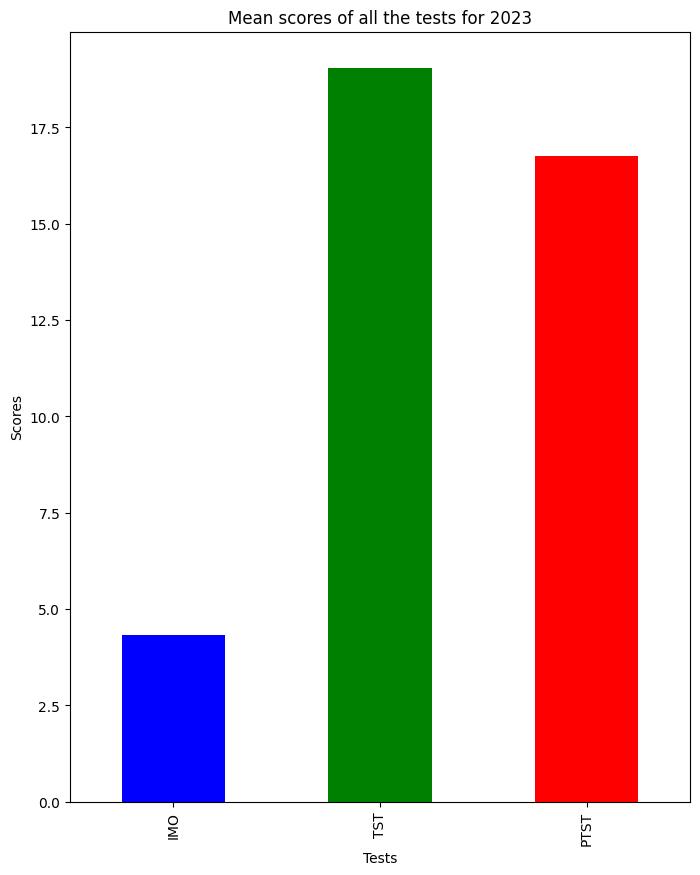

In [18]:
mean_calc(comparing_2023,2023)# calls and calculates mean for 2023


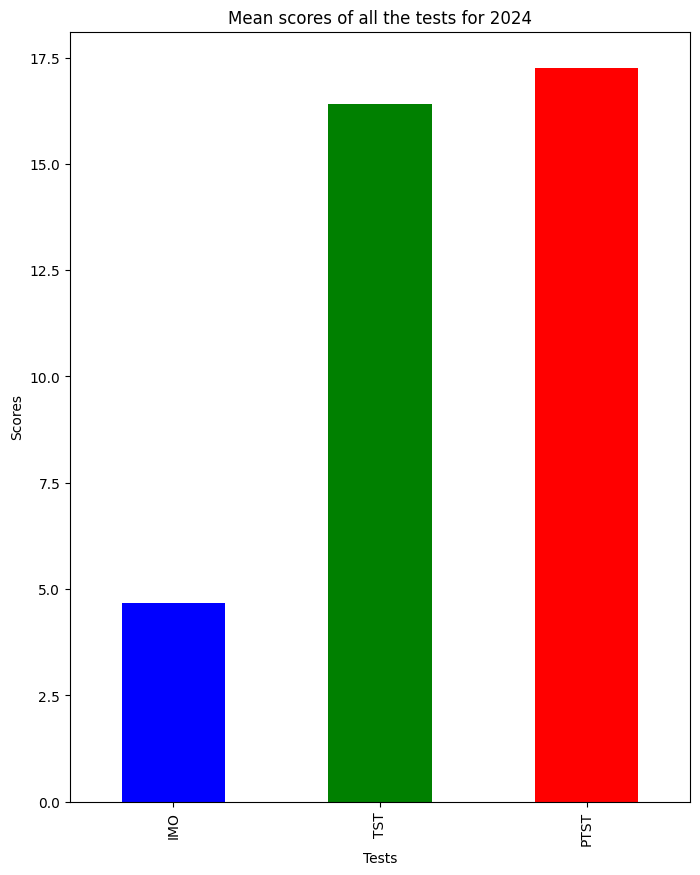

In [19]:
mean_calc(comparing_2024,2024)# calls and calculates mean for 2024

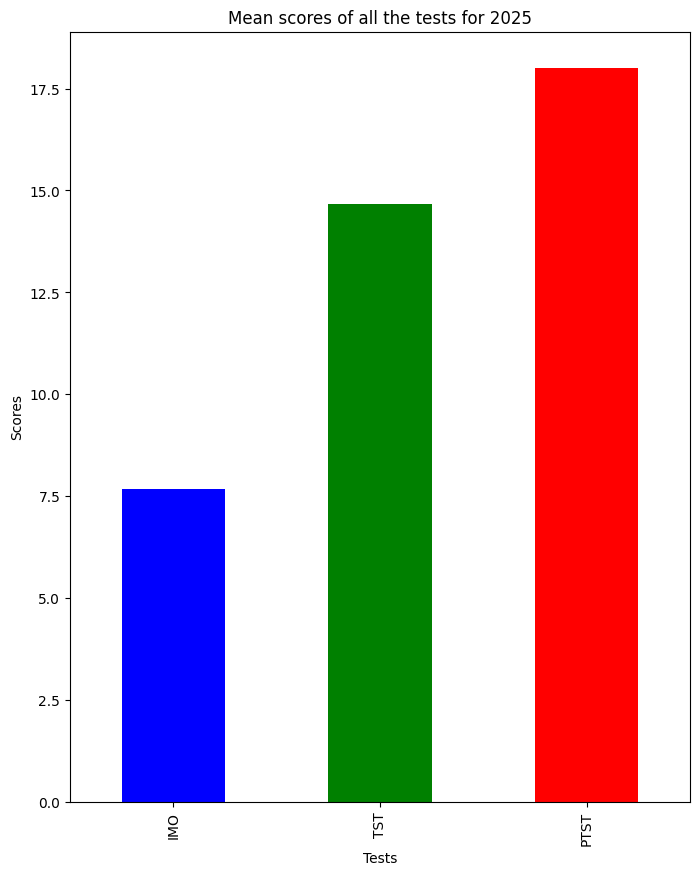

In [20]:
mean_calc(comparing_2025,2025)# calls and calculates mean for 2025

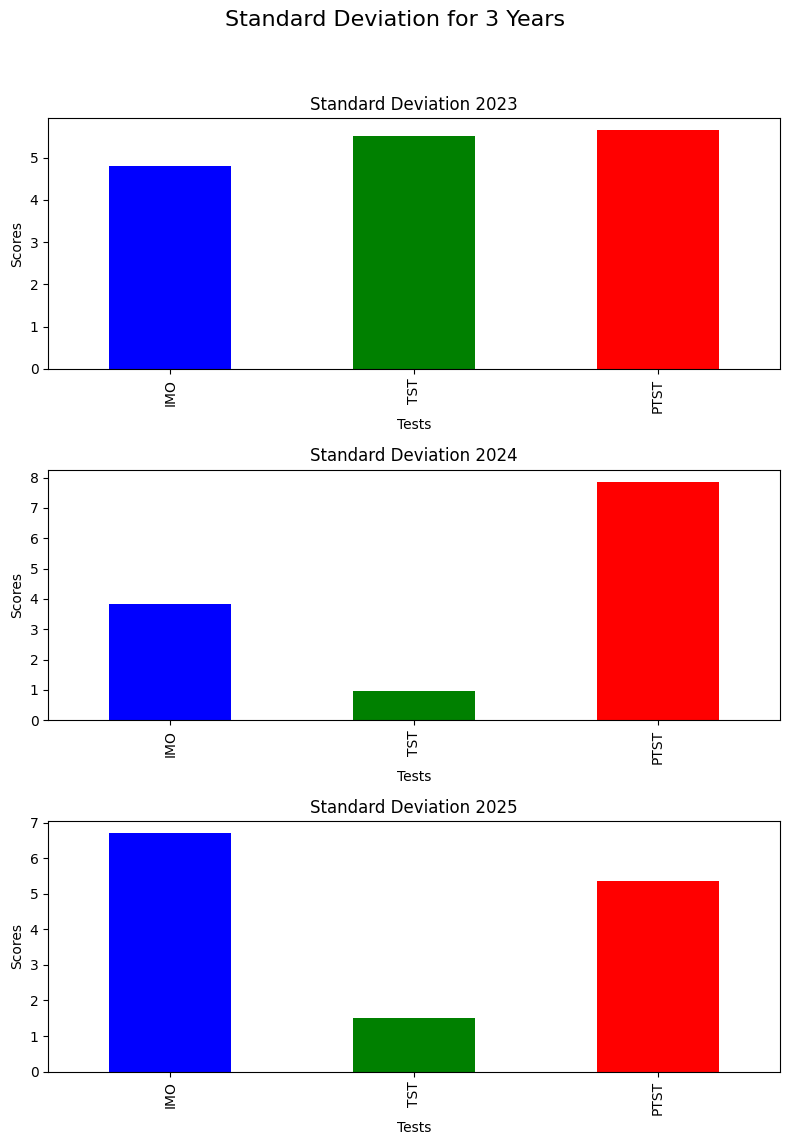

In [21]:
fig, axes = mp.subplots(nrows=3, ncols=1, figsize=(8, 12))# forms a 3 by 1 subplot to print dataframe for 3 years

comparing_2023.std().plot(ax=axes[0], kind="bar", color=["Blue","Green","Red"])
axes[0].set_title("Standard Deviation 2023")#plots standard deviation of 2023

comparing_2024.std().plot(ax=axes[1], kind="bar", color=["Blue","Green","Red"])
axes[1].set_title("Standard Deviation 2024")#plots standard deviation of 2024

comparing_2025.std().plot(ax=axes[2], kind="bar", color=["Blue","Green","Red"])
axes[2].set_title("Standard Deviation 2025")#plots standard deviation of 2025

fig.suptitle("Standard Deviation for 3 Years", fontsize=16)
for ax in axes:
    ax.set_xlabel("Tests")
    ax.set_ylabel("Scores")# sets common label across all three datasets


mp.tight_layout(rect=[0, 0.03, 1, 0.95])#Value calculated and entered to reduce overlap

mp.savefig("standard_deviation.png", dpi=300)
mp.show()